# 05 · Real data: bike sharing and highway traffic, day by day

Two public UCI datasets, one **window per day**:

* **Capital Bikeshare**, hourly rentals, Washington DC, 2011-12;
* **I-94 Metro Interstate**, hourly westbound traffic, Minneapolis, 2012-18.

The input is the hour ($x = 2\pi h/24$); the response is $\log(1+\text{count})$
minus that day's mean, so the level of the season is gone and a regime can
only be the **shape** of the daily law. The reference labels are the
calendar day type — a *proxy*, used for scoring only. The first run
downloads the two archives (~0.7 MB) into `.cache/` and checks their sha256.

In [1]:
import sys, pathlib
ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "pyproject.toml").exists())
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from lrdsr import viz
viz.style()
pd.set_option("display.precision", 4)
RES = ROOT / "results"

In [2]:
from experiments.realdata.windows import load
from experiments.realdata.run import fourier

data = {name: load(name) for name in ("bike", "traffic")}
for name, d in data.items():
    print(f"{name:8s} {d.X_seq.shape[0]:5d} days x {d.X_seq.shape[1]} hours; "
          f"working-day share {d.reference.mean():.2f}; coverage {d.coverage}")

bike       723 days x 24 hours; working-day share 0.68; coverage {'dataset': 'bike', 'days_raw': 731, 'days_kept': 723, 'days_dropped_incomplete': 8, 'hours_zero_filled': 74, 'working_share': 0.6832641770401107}
traffic   1214 days x 24 hours; working-day share 0.68; coverage {'dataset': 'traffic', 'days_raw': 1860, 'days_kept': 1214, 'days_dropped_incomplete': 646, 'hours_zero_filled': 0, 'working_share': 0.6779242174629324}


## 1 · What the days look like

Every day, drawn as a thin line and coloured by the calendar. The two daily
laws are visible by eye: a commuting double peak and a single midday hump.

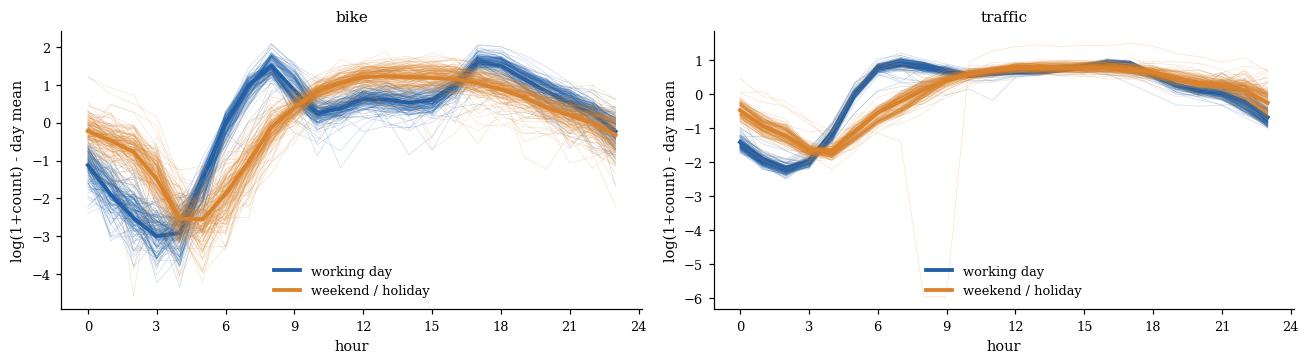

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
hours = np.arange(24)
for a, (name, d) in zip(ax, data.items()):
    for k, lab in ((1, "working day"), (0, "weekend / holiday")):
        sel = np.flatnonzero(d.reference == k)[:150]
        a.plot(hours, d.y_seq[sel].T, color=viz.regime_color(1 - k), lw=0.4, alpha=0.25)
        a.plot(hours, d.y_seq[d.reference == k].mean(0), color=viz.regime_color(1 - k),
               lw=2.5, label=lab)
    a.set(title=name, xlabel="hour", ylabel="log(1+count) - day mean", xticks=range(0, 25, 3))
    a.legend(loc="lower center")
fig.tight_layout()

## 2 · Fit, live: hard loop and soft EM

`K = 2`, no labels. The soft EM uses a Fourier basis of four harmonics — the
basis a practitioner would reach for with a daily cycle — and the hard loop
the fast symbolic library.

In [4]:
from lrdsr import GroupedDCSR, SoftLRDSR
from lrdsr.core.evaluation import clustering_metrics
from experiments.common.fitting import window_features

fits = {}
for name, d in data.items():
    Zf, _ = window_features(d.X_seq, d.y_seq)
    hard = GroupedDCSR(n_clusters=2, alpha_geom=0.0, init="mechanism", residual_scale="global",
                       random_state=11).fit(d.X_seq, d.y_seq, Zf, feature_names=["x"])
    soft = SoftLRDSR(2, basis=fourier, noise="student_t", random_state=11).fit(d.X_seq, d.y_seq)
    fits[name] = (hard, soft)
    print(f"{name:8s} hard ARI {clustering_metrics(d.reference, hard.labels)['ARI']:.3f} | "
          f"soft ARI {clustering_metrics(d.reference, soft.labels)['ARI']:.3f} | "
          f"learned tail nu per regime {soft.nu.round(1)}")
    for m in hard.models:
        print("     law:", m.expression())

bike     hard ARI 0.912 | soft ARI 0.944 | learned tail nu per regime [4.1 3.1]
     law: 2.5254 -1.3556*sin(x) -2.1526*cos(x) -0.36593*sin(2*x) -2.9022*log1p(abs(x)) +0.019837*(x)^3
     law: -1.035 +1.3048*log1p(abs(x)) -0.49835*cos(x) -0.97062*sin(2*x) -1.0108*sin(x) -0.01068*(x)^3


traffic  hard ARI 0.921 | soft ARI 0.927 | learned tail nu per regime [3.7 2.5]
     law: 0.70451 -2.2653*log1p(abs(x)) -1.1027*cos(x) +0.71361*x -0.31182*sin(2*x) -0.49855*sin(x)
     law: -1.8041 -0.12715*cos(x) +0.67823*log1p(abs(x)) -0.32225*sin(2*x) -0.021664*(x)^3 +0.72534*x


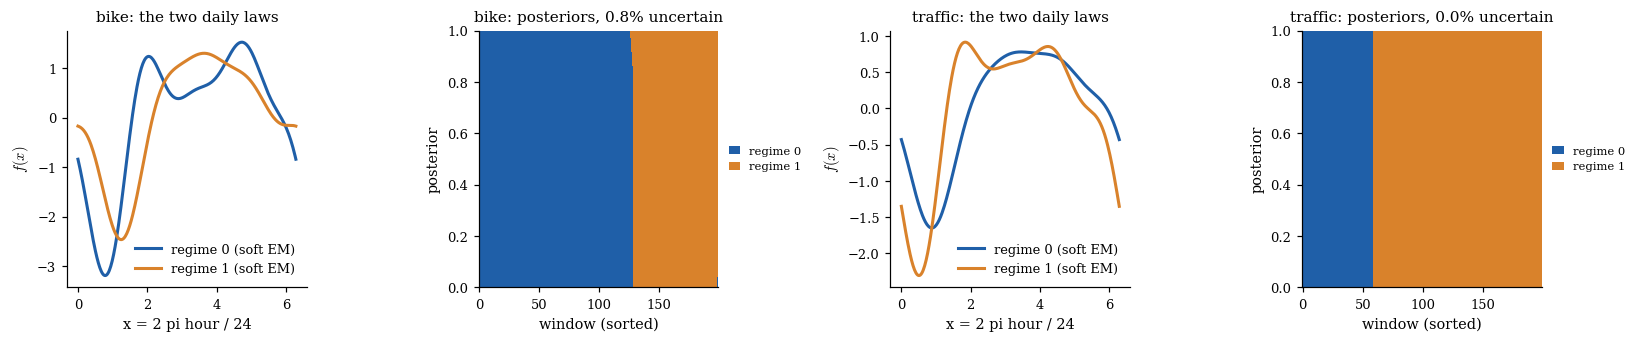

In [5]:
fig, ax = plt.subplots(1, 4, figsize=(15, 3.2))
xg = np.linspace(0, 2 * np.pi, 200)
for i, (name, d) in enumerate(data.items()):
    hard, soft = fits[name]
    viz.plot_laws(coef=soft.coef, basis=fourier, x_range=(0, 2 * np.pi), ax=ax[2 * i],
                  labels=[f"regime {k} (soft EM)" for k in range(2)])
    ax[2 * i].set(title=f"{name}: the two daily laws", xlabel="x = 2 pi hour / 24")
    viz.plot_responsibilities(soft.responsibilities, ax=ax[2 * i + 1])
    ax[2 * i + 1].set_title(f"{name}: posteriors, {np.mean(soft.entropy > 0.1):.1%} uncertain")
fig.tight_layout()

## 3 · The committed comparison, every method

Mean over seeds {11, 23, 42}, from `results/realdata/realdata_summary.csv`.

In [6]:
S = pd.read_csv(RES / "realdata" / "realdata_summary.csv")
S.pivot_table(index=["family", "method"], columns="dataset", values="ARI_mean").round(3)

dataset                                               bike  traffic
family            method                                           
LR-DSR            lrdsr_alpha0                       0.915    0.921
                  lrdsr_alpha0.25                    0.917    0.924
geometry          geom_Bayesian GMM (full cov)       0.297    0.001
                  geom_Birch                         0.454    0.003
                  geom_Fuzzy c-means                 0.462    0.574
                  geom_GMM (full cov)                0.320    0.001
                  geom_K-means                       0.473    0.004
                  geom_Spectral (RBF kernel)         0.611    0.002
                  geom_Ward agglomerative            0.450    0.003
                  geom_best (Fuzzy c-means)            NaN    0.574
                  geom_best (Spectral (RBF kernel))  0.611      NaN
mechanism K-means mech_fourier                       0.955    0.927
                  mech_kmeans                        0.917    0.924
raw profile       raw_profile_kmeans                 0.955    0.927
soft EM           soft_fourier                       0.955    0.927
                  soft_gaussian                      0.939    0.924
                  soft_student_t                     0.955    0.924

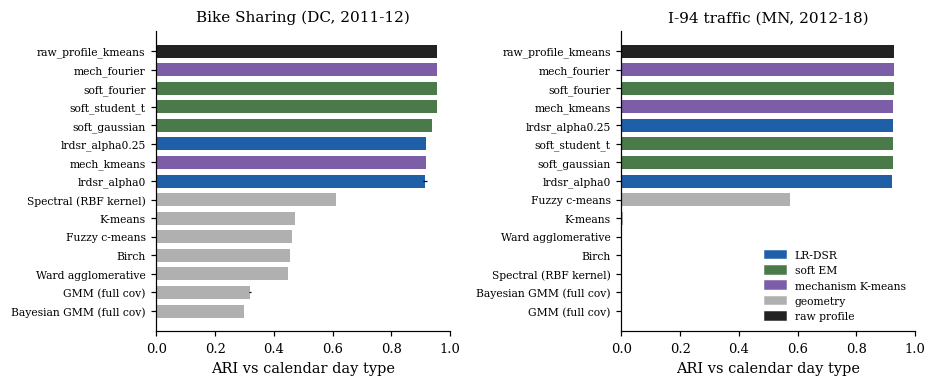

In [7]:
from analysis.figs_realdata import FIGURES as RF
RF["realdata_methods"]();

**A K-means on the raw 24-hour profile ties the best method on both
datasets.** That is the expected result, not a surprise: every day has the
same 24-hour design, so mechanism space is only a linear change of
coordinates of the profile. The method's advantage on the simulator — windows
whose *inputs differ* — does not exist here. What it adds on this data is the
laws, the posteriors, the label-free separation, and the real-time version.

## 4 · Where the law and the calendar disagree

The separation between the two laws is large, so the implied ceiling is
essentially zero error. The disagreements are therefore worth reading one by
one — they are almost all days the **calendar** gets wrong.

In [8]:
pd.read_csv(RES / "realdata" / "realdata_rho.csv")[
    ["dataset", "basis", "sigma", "rho_trace", "ceiling_trace", "best_error"]]

,dataset,basis,sigma,rho_trace,ceiling_trace,best_error
0,bike,library,0.5156,1.6420,8.4819e-04,0.0111
1,bike,fourier,0.2872,12.0518,9.1914e-18,0.0111
2,traffic,library,0.2397,3.9796,5.1332e-07,0.0181
3,traffic,fourier,0.1391,17.9108,1.7605e-25,0.0181


In [9]:
pd.read_csv(RES / "realdata" / "realdata_disagreements.csv")

,dataset,date,weekday,day_type,holiday,behaves_like
0,bike,2011-04-15,4,holiday,holiday,working
1,bike,2011-10-10,0,holiday,holiday,working
2,bike,2011-11-11,4,holiday,holiday,working
3,bike,2011-11-25,4,working,NaN,off
4,bike,2012-04-16,0,holiday,holiday,working
5,bike,2012-10-08,0,holiday,holiday,working
6,bike,2012-11-12,0,holiday,holiday,working
7,bike,2012-12-24,0,working,NaN,off
8,traffic,2012-10-08,0,holiday,Columbus Day,working
9,traffic,2012-11-12,0,holiday,Veterans Day,working


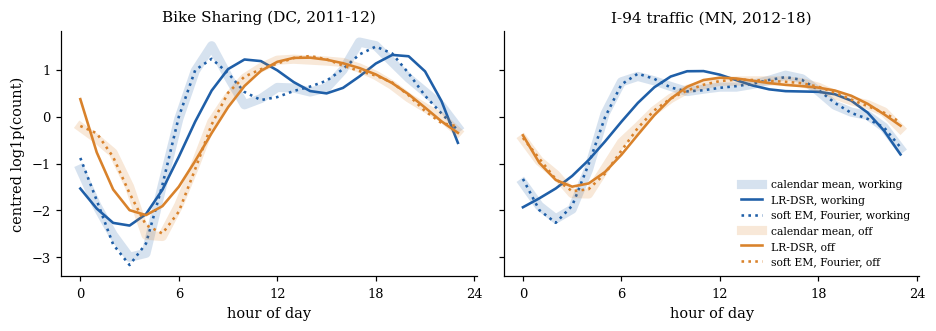

In [10]:
RF["realdata_laws"]();

## 5 · Choosing K, honestly

BIC over `K = 1…8` keeps improving to the largest `K`: the likelihood treats
24 autocorrelated hours as independent, and real days vary in many ways. The
table shows it, and the contingency tables show what the first extra
cluster is.

In [11]:
K = pd.read_csv(RES / "realdata" / "realdata_k_selection.csv")
K.pivot_table(index="K", columns=["dataset", "basis"], values="ARI_vs_daytype").round(3)

dataset    bike         traffic        
basis   fourier library fourier library
K                                      
1         0.000   0.000   0.000   0.000
2         0.955   0.939   0.927   0.924
3         0.639   0.877   0.886   0.920
4         0.441   0.804   0.803   0.826
5         0.345   0.781   0.423   0.556
6         0.282   0.754   0.352   0.535
7         0.253   0.748   0.333   0.520
8         0.233   0.751   0.321   0.504

In [12]:
C = pd.read_csv(RES / "realdata" / "realdata_contingency.csv")
C.head(20)

,dataset,basis,K,is_chosen_K,cluster,variable,value,n_days
0,bike,library,2,False,0,day_type,holiday,7
1,bike,library,2,False,0,day_type,weekend,3
2,bike,library,2,False,0,day_type,working,493
3,bike,library,2,False,1,day_type,holiday,14
4,bike,library,2,False,1,day_type,weekend,205
5,bike,library,2,False,1,day_type,working,1
6,bike,library,2,False,0,weekday,0,94
7,bike,library,2,False,0,weekday,1,100
8,bike,library,2,False,0,weekday,2,102
9,bike,library,2,False,0,weekday,3,101


## 6 · In real time, over the calendar

Warm-started on the first 60 days without labels, then fed one day at a time
in date order: each day is assigned the moment it ends, and the laws are
updated with it.

accuracy against the calendar: 0.989 on 636 days; 27 held as novel


<Axes: title={'center': 'bike, day by day: calendar (top) vs online assignment'}, xlabel='window (arrival order)'>

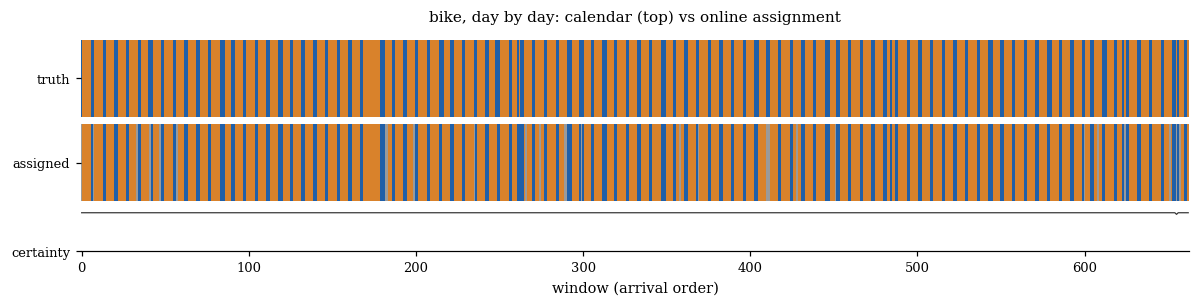

In [13]:
from lrdsr import OnlineLRDSR
from lrdsr.core.evaluation import aligned_accuracy

d = data["bike"]
on = OnlineLRDSR(basis=fourier, novelty_alpha=1e-6).warm_start(d.X_seq[:60], d.y_seq[:60],
                                                                n_clusters=2)
tl = on.fit_stream(d.X_seq[60:], d.y_seq[60:], true_labels_for_eval=d.reference[60:])
ok = tl.label >= 0
print(f"accuracy against the calendar: {aligned_accuracy(tl.truth[ok], tl.label[ok]):.3f} "
      f"on {ok.sum()} days; {(~ok).sum()} held as novel")
fig, ax = plt.subplots(figsize=(13, 2.6))
viz.plot_stream(tl, ax=ax, title="bike, day by day: calendar (top) vs online assignment")

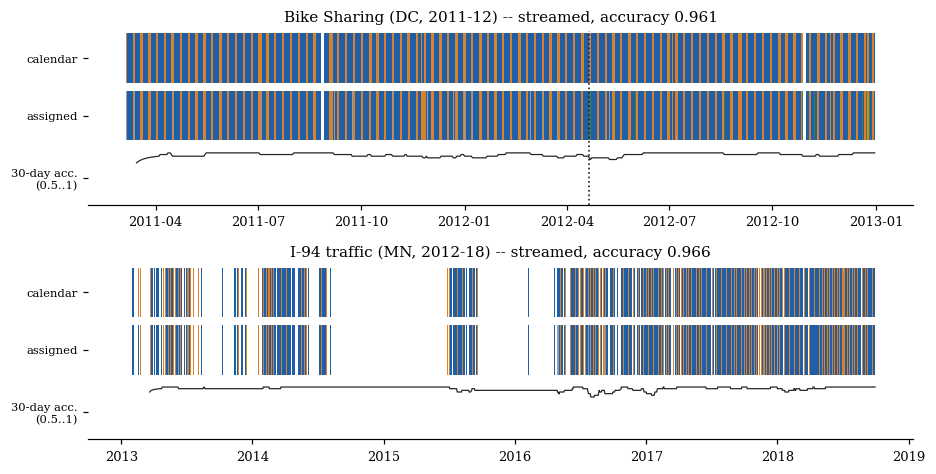

In [14]:
RF["realdata_online"]();

In [15]:
pd.read_csv(RES / "realdata" / "realdata_online_summary.csv")

,dataset,novelty_alpha,warmup_days,streamed_days,final_regimes,births,buffered_days,online_accuracy,online_ARI,batch_error_lrdsr_all_days,birth_log
0,bike,1.0000e-03,60,663,3,1,15,0.9608,0.8896,0.0212,"regime 2 born 2012-04-21 (9 days: working=5, w..."
1,bike,1.0000e-06,60,663,2,0,9,0.9759,0.9340,0.0212,NaN
2,traffic,1.0000e-03,60,1154,2,0,21,0.9662,0.9041,0.0198,NaN
3,traffic,1.0000e-06,60,1154,2,0,13,0.9723,0.9140,0.0198,NaN
